# Analysis Notebook

Load saved numpy results and generate figures (no model loading).

In [1]:
%matplotlib inline

import json
import csv
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from experiment_utils import backfill_method_curve_stats, find_method_result_path
from metrics_utils import compute_d_arch_auc, compute_sensitivity_ratio
from viz_utils import (
    METRIC_AXIS_LABELS,
    METRIC_TABLE_TITLES,
    add_attention_rollout_entropy_overlay,
    add_logit_corr_band,
    load_arch_baseline_maps,
    method_display_name,
    load_attention_rollout_entropy,
    CASCADE_DISPLAY_PRESETS,
    plot_cascade_paper_grid,
    plot_cascading_grid,
    load_occlusion_auc_summary,
    plot_occlusion_auc_by_fraction,
    plot_occlusion_faithfulness_curves,
    select_depth_indices,
    show_figure,
    _load_step0_target_confidence,
    _occlusion_mean_std_curve,
)
from experiment_utils import DEFAULT_PATCH_FRACTIONS, _occlusion_fraction_suffix

RESULTS_ROOT = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CLASS_A_METHODS = ["gradient", "input_grad", "ig"]
CLASS_B_METHODS = {
    "resnet50": ["gradcam"],
    "vit": ["transformer_gradcam"],
}
CLASS_C_METHODS = {
    "resnet50": ["gbp"],
    "vit": ["attention_rollout"],
}
ARCHS = {
    "resnet50": {"title": "ResNet-50"},
    "vit": {"title": "ViT-B/16"},
}
for arch in ARCHS:
    ARCHS[arch]["methods"] = (
        CLASS_A_METHODS + CLASS_B_METHODS[arch] + CLASS_C_METHODS[arch]
    )
    for method in ARCHS[arch]["methods"]:
        backfill_method_curve_stats(RESULTS_ROOT / arch, arch, method)

MECH_ARCH_TAGS = [
    ("resnet", "ResNet-50"),
    ("vit", "ViT-B/16"),
]
PRIMARY_SPEARMAN = {
    "ig": "spearman_rms_mean",
    "input_grad": "spearman_rms_mean",
}
DEFAULT_PRIMARY_SPEARMAN = "spearman_abs_rms_mean"
CLASS_B_SPATIAL = {
    "resnet50": "gradcam",
    "vit": "transformer_gradcam",
}


In [2]:

def _load_order(arch):
    for base in [RESULTS_ROOT / arch, *sorted((RESULTS_ROOT / arch).glob("seed*"))]:
        order_path = base / "randomization_order.json"
        if order_path.exists():
            with open(order_path) as f:
                return json.load(f)
    return []


def _fraction_x(n_depths):
    if n_depths <= 1:
        return np.array([0.0])
    return np.linspace(0.0, 1.0, n_depths)


def _metric_suffix(method, metric="spearman"):
    if metric == "spearman":
        return PRIMARY_SPEARMAN.get(method, DEFAULT_PRIMARY_SPEARMAN)
    if metric == "ssim_abs_rms":
        return "ssim_abs_rms_mean"
    # metric == "ssim": signed RMS for IG/input_grad, |.| RMS for other methods
    if method in ("ig", "input_grad"):
        return "ssim_rms_mean"
    return "ssim_abs_rms_mean"


def _method_dirs(arch, method):
    base = RESULTS_ROOT / arch
    if method in CLASS_A_METHODS:
        seed_dirs = sorted(base.glob("seed*"))
        if seed_dirs:
            return seed_dirs
    return [base]


def _load_curves(arch, method, metric="spearman"):
    suffix = _metric_suffix(method, metric=metric)
    pattern = "%%s_%s.npy" % suffix
    curves = []
    for d in _method_dirs(arch, method):
        path = find_method_result_path(d, method, pattern)
        if path is not None:
            curves.append(np.load(path))
    return curves


def _mean_std_curve(arch, method, metric="spearman"):
    curves = _load_curves(arch, method, metric=metric)
    if not curves:
        return None, None
    min_len = min(len(c) for c in curves)
    arr = np.stack([c[:min_len] for c in curves])
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)


def _plot_curve_with_band(ax, x, mean, std, label, **kwargs):
    ax.plot(x, mean, marker="o", markersize=3, label=label, **kwargs)
    if std is not None and np.any(std > 0):
        ax.fill_between(x, mean - std, mean + std, alpha=0.18)


def _show_fig(fig, out_path=None, dpi=150):
    if out_path is not None:
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        print("Saved", out_path)
    show_figure(fig)


def _apply_arch_overlays(ax, arch, order, x):
    add_logit_corr_band(ax, RESULTS_ROOT, arch, x_values=x, annotate_resnet_skip=False)


def _layer_label(order, depth):
    if depth == 0:
        return "pretrained"
    idx = depth - 1
    return order[idx] if idx < len(order) else ""


def _fmt_value(mean, std, precision=4):
    if std is not None and np.isfinite(std) and std > 0:
        return ("%%.%df ± %%.%df") % (precision, precision) % (mean, std)
    return ("%%.%df") % precision % mean


def _pivot_rows(long_rows, index_cols, column_col, value_col):
    if not long_rows:
        return [], index_cols
    col_names = sorted({str(r[column_col]) for r in long_rows})
    index_keys = []
    index_map = {}
    for row in long_rows:
        key = tuple(row[c] for c in index_cols)
        if key not in index_map:
            index_map[key] = {}
            index_keys.append(key)
        index_map[key][str(row[column_col])] = row[value_col]
    wide_rows = []
    for key in index_keys:
        wide = {index_cols[i]: key[i] for i in range(len(index_cols))}
        for col in col_names:
            wide[col] = index_map[key].get(col, "")
        wide_rows.append(wide)
    return wide_rows, index_cols + col_names


def _display_table(rows, title, csv_name=None, columns=None):
    if not rows:
        print("No data for %s" % title)
        return
    if columns is None:
        columns = list(rows[0].keys())
    display(Markdown("#### %s" % title))
    html = ["<table><thead><tr>"]
    html.extend("<th>%s</th>" % c for c in columns)
    html.append("</tr></thead><tbody>")
    for row in rows:
        html.append("<tr>")
        for col in columns:
            html.append("<td>%s</td>" % row.get(col, ""))
        html.append("</tr>")
    html.append("</tbody></table>")
    display(HTML("".join(html)))
    if csv_name is not None:
        out = FIGURES_DIR / csv_name
        with open(out, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=columns, extrasaction="ignore")
            writer.writeheader()
            writer.writerows(rows)
        print("Saved", out)


def build_cascade_curve_table(arch, metric="spearman", methods=None):
    order = _load_order(arch)
    methods = methods or ARCHS[arch]["methods"]
    rows = []
    for method in methods:
        mean, std = _mean_std_curve(arch, method, metric=metric)
        if mean is None:
            continue
        if std is None:
            std = np.full_like(mean, np.nan, dtype=float)
        for depth, (m, s) in enumerate(zip(mean, std)):
            rows.append(
                {
                    "depth": depth,
                    "layer": _layer_label(order, depth),
                    "method": method_display_name(method),
                    "value": _fmt_value(float(m), float(s)),
                }
            )
    wide_rows, columns = _pivot_rows(rows, ["depth", "layer"], "method", "value")
    return wide_rows, columns


def display_cascade_curve_tables(metric="spearman", methods=None, title_suffix="", arch=None):
    items = [(arch, ARCHS[arch])] if arch is not None else ARCHS.items()
    for arch_key, cfg in items:
        table, columns = build_cascade_curve_table(arch_key, metric=metric, methods=methods)
        suffix = (" " + title_suffix) if title_suffix else ""
        _display_table(
            table,
            "%s cascade %s%s" % (cfg["title"], METRIC_TABLE_TITLES.get(metric, metric), suffix),
            csv_name="table_within_arch_%s_%s.csv" % (arch_key, metric),
            columns=columns,
        )


def _load_logit_corr_for_arch(arch):
    tag = {"resnet50": "resnet", "vit": "vit"}.get(arch, arch)
    path = RESULTS_ROOT / "mechanistic" / ("logit_corr_%s.npy" % tag)
    if not path.exists():
        return None
    return np.load(path)


def build_attention_diagnostics_table():
    arch = "vit"
    method = "attention_rollout"
    mean, std = _mean_std_curve(arch, method, metric="spearman")
    if mean is None:
        return []
    order = _load_order(arch)
    logit_corr = _load_logit_corr_for_arch(arch)
    entropy = load_attention_rollout_entropy(RESULTS_ROOT / arch)
    frac = _fraction_x(len(mean))
    rows = []
    for depth, (m, s, f) in enumerate(zip(mean, std if std is not None else [np.nan] * len(mean), frac)):
        row = {
            "depth": depth,
            "layer": _layer_label(order, depth),
            "fractional_depth": ("%.4f" % f),
            "spearman": _fmt_value(float(m), float(s)),
        }
        if logit_corr is not None and depth < len(logit_corr):
            row["logit_pearson_r"] = ("%.4f" % float(logit_corr[depth]))
        if entropy is not None and depth < len(entropy):
            row["attention_entropy"] = ("%.4f" % float(entropy[depth]))
        rows.append(row)
    return rows


def build_logit_corr_table():
    rows = []
    mech = RESULTS_ROOT / "mechanistic"
    for tag, label in MECH_ARCH_TAGS:
        path = mech / ("logit_corr_%s.npy" % tag)
        if not path.exists():
            continue
        vals = np.load(path)
        frac = _fraction_x(len(vals))
        for depth, (f, v) in enumerate(zip(frac, vals)):
            rows.append(
                {
                    "architecture": label,
                    "depth": depth,
                    "fractional_depth": ("%.4f" % float(f)),
                    "logit_pearson_r": ("%.4f" % float(v)),
                }
            )
    if not rows:
        return [], []
    wide_rows, columns = _pivot_rows(
        rows, ["depth", "fractional_depth"], "architecture", "logit_pearson_r"
    )
    return wide_rows, columns


def build_activation_scale_summary_table():
    rows = []
    mech = RESULTS_ROOT / "mechanistic"
    for tag, label in MECH_ARCH_TAGS:
        files = sorted(mech.glob("activation_scale_%s_depth*.npy" % tag))
        for path in files:
            depth = int(path.stem.split("depth")[-1])
            arr = np.load(path).ravel()
            arr = arr[np.isfinite(arr)]
            if arr.size == 0:
                continue
            rows.append(
                {
                    "architecture": label,
                    "depth": depth,
                    "n": int(arr.size),
                    "mean": ("%.6g" % float(np.mean(arr))),
                    "median": ("%.6g" % float(np.median(arr))),
                    "std": ("%.6g" % float(np.std(arr))),
                    "p99": ("%.6g" % float(np.percentile(arr, 99))),
                }
            )
    return rows


def build_occlusion_faithfulness_table(patch_fraction=0.20):
    mech_tags = {"resnet50": "resnet", "vit": "vit"}
    suffix = _occlusion_fraction_suffix(patch_fraction)
    rows = []
    for arch, cfg in ARCHS.items():
        step0 = _load_step0_target_confidence(RESULTS_ROOT, arch, mech_tags)
        for method in cfg["methods"]:
            arch_dir = RESULTS_ROOT / arch
            curve_path = find_method_result_path(
                arch_dir, method, "occlusion_%s_curve%s.npy" % ("%s", suffix)
            ) or (arch_dir / ("occlusion_%s_curve%s.npy" % (method, suffix)))
            mean, std, has_step0 = _occlusion_mean_std_curve(curve_path, step0)
            if mean is None:
                continue
            steps = np.arange(len(mean)) if has_step0 else np.arange(1, len(mean) + 1)
            if std is None:
                std = np.full_like(mean, np.nan, dtype=float)
            for step, (m, s) in zip(steps, zip(mean, std)):
                rows.append(
                    {
                        "architecture": cfg["title"],
                        "method": method_display_name(method),
                        "step": int(step),
                        "value": _fmt_value(float(m), float(s)),
                    }
                )
    if not rows:
        return [], []
    wide_rows, columns = _pivot_rows(rows, ["architecture", "step"], "method", "value")
    return wide_rows, columns


def build_occlusion_auc_table():
    rows = []
    for row in load_occlusion_auc_summary(RESULTS_ROOT, ARCHS):
        rows.append(
            {
                "architecture": row["architecture"],
                "method": method_display_name(row["method"]),
                "patch_fraction": ("%.2f" % float(row["patch_fraction"])),
                "n_tiles": row.get("n_tiles", ""),
                "n_occluded": row.get("n_occluded", ""),
                "n_images": row.get("n_images", ""),
                "auc_mean": ("%.4f" % float(row["auc_mean"])),
                "auc_std": ("%.4f" % float(row["auc_std"])),
                "auc_median": ("%.4f" % float(row["auc_median"])),
            }
        )
    return rows


Saved /Users/alexatran/saliency_and_attention/results/figures/within_arch_resnet50_spearman.png


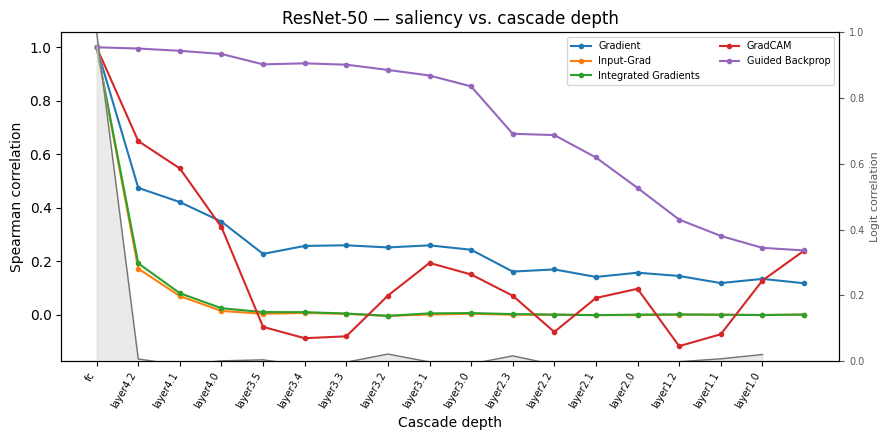

Saved /Users/alexatran/saliency_and_attention/results/figures/within_arch_vit_spearman.png


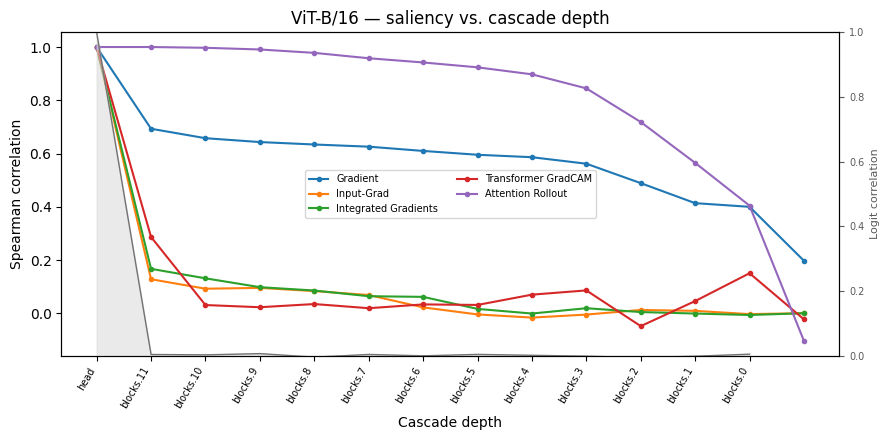

In [3]:

def plot_within_architecture_curves(metric="spearman"):
    for arch, cfg in ARCHS.items():
        order = _load_order(arch)
        fig, ax = plt.subplots(figsize=(9, 4.5))
        for method in cfg["methods"]:
            mean, std = _mean_std_curve(arch, method, metric=metric)
            if mean is None:
                continue
            x = np.arange(len(mean))
            _plot_curve_with_band(ax, x, mean, std, method_display_name(method))
        x_depths = np.arange(len(order))
        _apply_arch_overlays(ax, arch, order, x_depths)
        ax.set_xlabel("Cascade depth")
        ax.set_ylabel(METRIC_AXIS_LABELS.get(metric, metric))
        ax.set_title("%s — saliency vs. cascade depth" % cfg["title"])
        if order:
            ax.set_xticks(np.arange(len(order)))
            ax.set_xticklabels(order, rotation=60, ha="right", fontsize=7)
        ax.legend(fontsize=7, ncol=2)
        fig.tight_layout()
        out = FIGURES_DIR / ("within_arch_%s_%s.png" % (arch, metric))
        _show_fig(fig, out)

plot_within_architecture_curves(metric="spearman")


### SSIM cascade curves

Saved /Users/alexatran/saliency_and_attention/results/figures/within_arch_resnet50_ssim.png


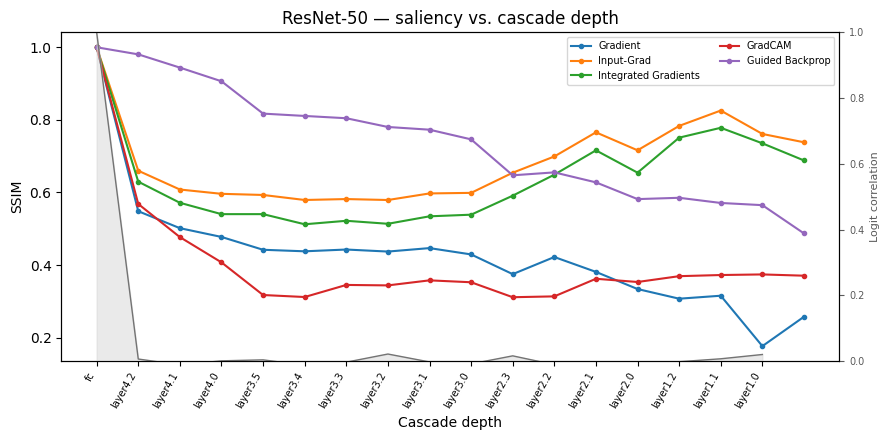

Saved /Users/alexatran/saliency_and_attention/results/figures/within_arch_vit_ssim.png


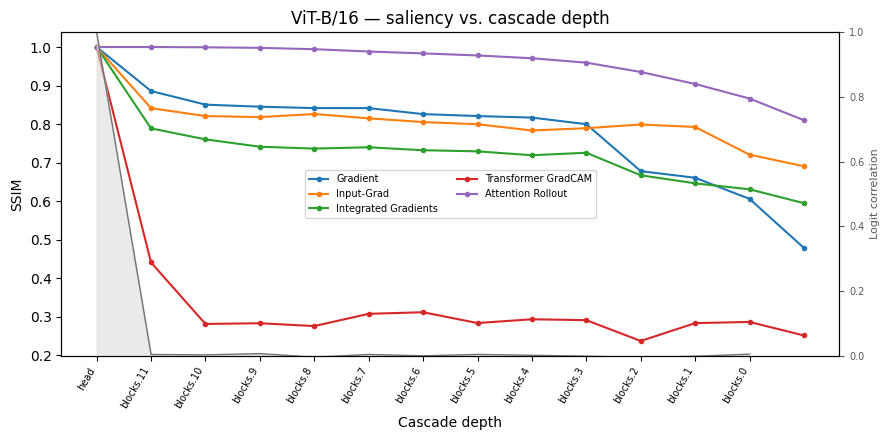

#### ResNet-50 cascade SSIM

depth,layer,GradCAM,Gradient,Guided Backprop,Input-Grad,Integrated Gradients
0,pretrained,1.0000,1.0000,1.0000,1.0000,1.0000
1,fc,0.5682,0.5482,0.9805,0.6598,0.6296
2,layer4.2,0.4769,0.5015,0.9440,0.6080,0.5715
3,layer4.1,0.4072,0.4773,0.9063,0.5962,0.5402
4,layer4.0,0.3173,0.4420,0.8172,0.5930,0.5402
5,layer3.5,0.3118,0.4377,0.8108,0.5792,0.5123
6,layer3.4,0.3451,0.4427,0.8045,0.5817,0.5218
7,layer3.3,0.3438,0.4370,0.7804,0.5791,0.5136
8,layer3.2,0.3577,0.4466,0.7729,0.5972,0.5342
9,layer3.1,0.3524,0.4292,0.7462,0.5988,0.5387


Saved /Users/alexatran/saliency_and_attention/results/figures/table_within_arch_resnet50_ssim.csv


#### ViT-B/16 cascade SSIM

depth,layer,Attention Rollout,Gradient,Input-Grad,Integrated Gradients,Transformer GradCAM
0,pretrained,1.0000,1.0000,1.0000,1.0000,1.0000
1,head,1.0000,0.8857,0.8412,0.7887,0.4404
2,blocks.11,0.9993,0.8504,0.8207,0.7602,0.2808
3,blocks.10,0.9978,0.8450,0.8180,0.7410,0.2826
4,blocks.9,0.9944,0.8414,0.8260,0.7363,0.2753
5,blocks.8,0.9884,0.8414,0.8148,0.7397,0.3071
6,blocks.7,0.9834,0.8258,0.8050,0.7320,0.3112
7,blocks.6,0.9781,0.8207,0.7995,0.7291,0.2832
8,blocks.5,0.9709,0.8168,0.7833,0.7189,0.2930
9,blocks.4,0.9594,0.7996,0.7892,0.7255,0.2906


Saved /Users/alexatran/saliency_and_attention/results/figures/table_within_arch_vit_ssim.csv
Saved /Users/alexatran/saliency_and_attention/results/figures/within_arch_resnet50_ssim_abs_rms.png


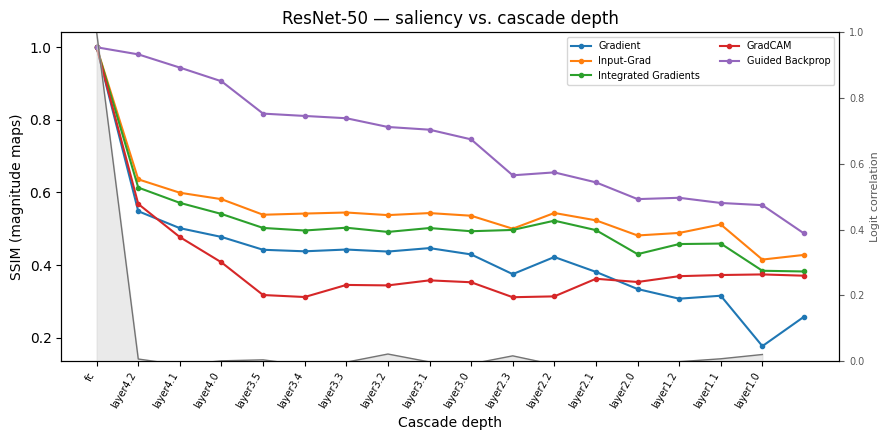

Saved /Users/alexatran/saliency_and_attention/results/figures/within_arch_vit_ssim_abs_rms.png


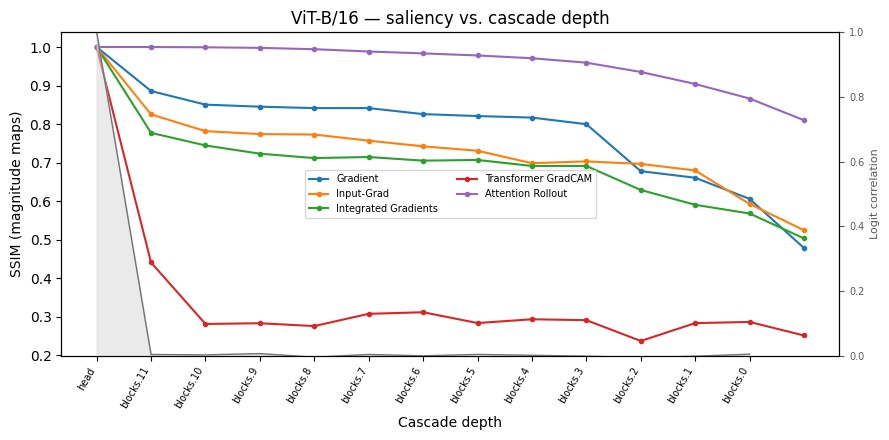

#### ResNet-50 cascade SSIM (magnitude maps)

depth,layer,GradCAM,Gradient,Guided Backprop,Input-Grad,Integrated Gradients
0,pretrained,1.0000,1.0000,1.0000,1.0000,1.0000
1,fc,0.5682,0.5482,0.9805,0.6361,0.6134
2,layer4.2,0.4769,0.5015,0.9440,0.5991,0.5713
3,layer4.1,0.4072,0.4773,0.9063,0.5814,0.5406
4,layer4.0,0.3173,0.4420,0.8172,0.5385,0.5022
5,layer3.5,0.3118,0.4377,0.8108,0.5418,0.4951
6,layer3.4,0.3451,0.4427,0.8045,0.5447,0.5028
7,layer3.3,0.3438,0.4370,0.7804,0.5375,0.4912
8,layer3.2,0.3577,0.4466,0.7729,0.5431,0.5019
9,layer3.1,0.3524,0.4292,0.7462,0.5358,0.4931


Saved /Users/alexatran/saliency_and_attention/results/figures/table_within_arch_resnet50_ssim_abs_rms.csv


#### ViT-B/16 cascade SSIM (magnitude maps)

depth,layer,Attention Rollout,Gradient,Input-Grad,Integrated Gradients,Transformer GradCAM
0,pretrained,1.0000,1.0000,1.0000,1.0000,1.0000
1,head,1.0000,0.8857,0.8250,0.7771,0.4404
2,blocks.11,0.9993,0.8504,0.7815,0.7444,0.2808
3,blocks.10,0.9978,0.8450,0.7739,0.7230,0.2826
4,blocks.9,0.9944,0.8414,0.7728,0.7116,0.2753
5,blocks.8,0.9884,0.8414,0.7568,0.7143,0.3071
6,blocks.7,0.9834,0.8258,0.7421,0.7049,0.3112
7,blocks.6,0.9781,0.8207,0.7306,0.7067,0.2832
8,blocks.5,0.9709,0.8168,0.6983,0.6912,0.2930
9,blocks.4,0.9594,0.7996,0.7030,0.6911,0.2906


Saved /Users/alexatran/saliency_and_attention/results/figures/table_within_arch_vit_ssim_abs_rms.csv


In [4]:
plot_within_architecture_curves(metric="ssim")
display_cascade_curve_tables(metric="ssim")
plot_within_architecture_curves(metric="ssim_abs_rms")
display_cascade_curve_tables(metric="ssim_abs_rms")

In [5]:
display(Markdown("### Cascade curve tables"))
display_cascade_curve_tables(metric="spearman")

### Cascade curve tables

#### ResNet-50 cascade Spearman

depth,layer,GradCAM,Gradient,Guided Backprop,Input-Grad,Integrated Gradients
0,pretrained,1.0000,1.0000,1.0000,1.0000,1.0000
1,fc,0.6493,0.4742,0.9953,0.1722,0.1919
2,layer4.2,0.5469,0.4211,0.9868,0.0696,0.0803
3,layer4.1,0.3273,0.3479,0.9750,0.0140,0.0241
4,layer4.0,-0.0457,0.2273,0.9361,0.0034,0.0097
5,layer3.5,-0.0880,0.2571,0.9400,0.0065,0.0094
6,layer3.4,-0.0809,0.2595,0.9349,0.0031,0.0044
7,layer3.3,0.0712,0.2515,0.9153,-0.0045,-0.0043
8,layer3.2,0.1935,0.2592,0.8943,0.0008,0.0049
9,layer3.1,0.1503,0.2428,0.8538,0.0033,0.0060


Saved /Users/alexatran/saliency_and_attention/results/figures/table_within_arch_resnet50_spearman.csv


#### ViT-B/16 cascade Spearman

depth,layer,Attention Rollout,Gradient,Input-Grad,Integrated Gradients,Transformer GradCAM
0,pretrained,1.0000,1.0000,1.0000,1.0000,1.0000
1,head,1.0000,0.6931,0.1279,0.1670,0.2866
2,blocks.11,0.9971,0.6576,0.0924,0.1314,0.0310
3,blocks.10,0.9908,0.6431,0.0954,0.0982,0.0229
4,blocks.9,0.9781,0.6340,0.0835,0.0856,0.0348
5,blocks.8,0.9579,0.6258,0.0687,0.0642,0.0192
6,blocks.7,0.9420,0.6098,0.0222,0.0617,0.0335
7,blocks.6,0.9237,0.5954,-0.0042,0.0166,0.0314
8,blocks.5,0.8975,0.5862,-0.0161,-0.0008,0.0701
9,blocks.4,0.8448,0.5618,-0.0048,0.0192,0.0860


Saved /Users/alexatran/saliency_and_attention/results/figures/table_within_arch_vit_spearman.csv


In [6]:

def note_cross_architecture_guardrail():
    print(
        "Raw cross-architecture cascade curves are intentionally omitted. "
        "Use the sensitivity-ratio table below for cross-architecture summaries."
    )

note_cross_architecture_guardrail()


Raw cross-architecture cascade curves are intentionally omitted. Use the sensitivity-ratio table below for cross-architecture summaries.


Saved /Users/alexatran/saliency_and_attention/results/figures/class_b_spatial_attribution_within_arch.png


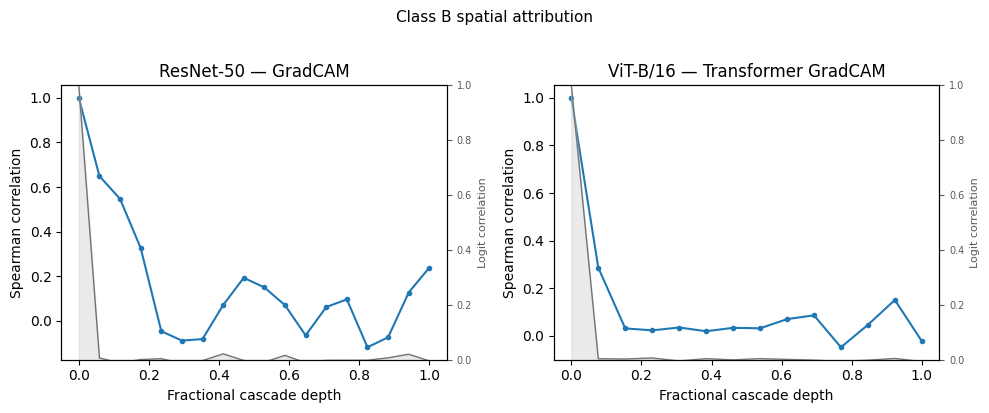

Saved /Users/alexatran/saliency_and_attention/results/figures/attention_diagnostics_vit.png


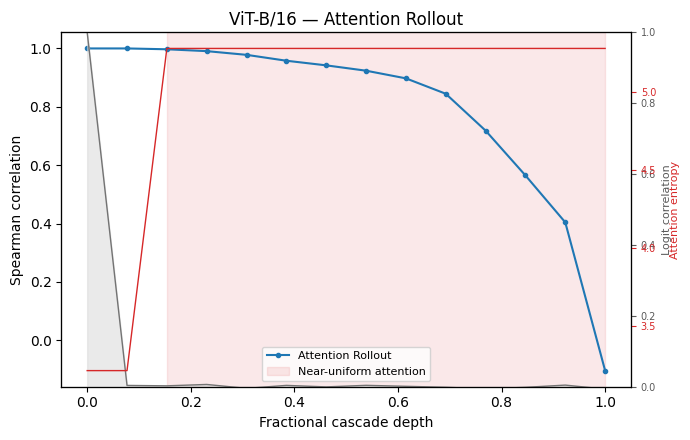

In [7]:

def plot_class_b_spatial_attribution():
    fig, axes = plt.subplots(1, len(CLASS_B_SPATIAL), figsize=(10, 4), sharey=False)
    if len(CLASS_B_SPATIAL) == 1:
        axes = [axes]
    for ax, arch in zip(axes, CLASS_B_SPATIAL):
        method = CLASS_B_SPATIAL[arch]
        mean, std = _mean_std_curve(arch, method, metric="spearman")
        order = _load_order(arch)
        if mean is None:
            ax.set_title("%s (missing)" % ARCHS[arch]["title"])
            continue
        x = _fraction_x(len(mean))
        _plot_curve_with_band(ax, x, mean, std, method_display_name(method))
        _apply_arch_overlays(ax, arch, order, x)
        ax.set_title("%s — %s" % (ARCHS[arch]["title"], method_display_name(method)))
        ax.set_xlabel("Fractional cascade depth")
        ax.set_ylabel(METRIC_AXIS_LABELS["spearman"])
    fig.suptitle("Class B spatial attribution", y=1.02, fontsize=11)
    fig.tight_layout()
    _show_fig(fig, FIGURES_DIR / "class_b_spatial_attribution_within_arch.png")


def plot_transformer_attention_diagnostics():
    arch = "vit"
    method = "attention_rollout"
    mean, std = _mean_std_curve(arch, method, metric="spearman")
    if mean is None:
        print("Skip ViT attention rollout diagnostics: curves missing")
        return
    fig, ax = plt.subplots(figsize=(7, 4.5))
    x_values = _fraction_x(len(mean))
    _plot_curve_with_band(ax, x_values, mean, std, method_display_name(method))
    add_logit_corr_band(
        ax, RESULTS_ROOT, arch, x_values=x_values, annotate_resnet_skip=False
    )
    ax2 = add_attention_rollout_entropy_overlay(
        ax, RESULTS_ROOT / arch, num_patches=196, x_values=x_values
    )
    if ax2 is not None:
        ax2.set_ylabel("Attention entropy", color="tab:red", fontsize=8, labelpad=10)
    ax.set_title("%s — Attention Rollout" % ARCHS[arch]["title"])
    ax.set_xlabel("Fractional cascade depth")
    ax.set_ylabel(METRIC_AXIS_LABELS["spearman"])
    ax.legend(fontsize=8, loc="best")
    fig.tight_layout()
    _show_fig(fig, FIGURES_DIR / "attention_diagnostics_vit.png")

plot_class_b_spatial_attribution()
plot_transformer_attention_diagnostics()


In [8]:
display(Markdown("### Class B / attention diagnostics tables"))
for arch, method in CLASS_B_SPATIAL.items():
    display_cascade_curve_tables(
        metric="spearman",
        methods=[method],
        arch=arch,
        title_suffix="(Class B spatial attribution)",
    )
_display_table(
    build_attention_diagnostics_table(),
    "ViT attention rollout diagnostics (numeric values)",
    csv_name="table_attention_diagnostics_vit.csv",
)

### Class B / attention diagnostics tables

#### ResNet-50 cascade Spearman (Class B spatial attribution)

depth,layer,GradCAM
0,pretrained,1.0000
1,fc,0.6493
2,layer4.2,0.5469
3,layer4.1,0.3273
4,layer4.0,-0.0457
5,layer3.5,-0.0880
6,layer3.4,-0.0809
7,layer3.3,0.0712
8,layer3.2,0.1935
9,layer3.1,0.1503


Saved /Users/alexatran/saliency_and_attention/results/figures/table_within_arch_resnet50_spearman.csv


#### ViT-B/16 cascade Spearman (Class B spatial attribution)

depth,layer,Transformer GradCAM
0,pretrained,1.0000
1,head,0.2866
2,blocks.11,0.0310
3,blocks.10,0.0229
4,blocks.9,0.0348
5,blocks.8,0.0192
6,blocks.7,0.0335
7,blocks.6,0.0314
8,blocks.5,0.0701
9,blocks.4,0.0860


Saved /Users/alexatran/saliency_and_attention/results/figures/table_within_arch_vit_spearman.csv


#### ViT attention rollout diagnostics (numeric values)

depth,layer,fractional_depth,spearman,logit_pearson_r,attention_entropy
0,pretrained,0.0000,1.0000,1.0000,3.2113
1,head,0.0769,1.0000,0.0037,3.2113
2,blocks.11,0.1538,0.9971,0.0025,5.2832
3,blocks.10,0.2308,0.9908,0.0064,5.2832
4,blocks.9,0.3077,0.9781,-0.0046,5.2832
5,blocks.8,0.3846,0.9579,0.0038,5.2832
6,blocks.7,0.4615,0.9420,-0.0005,5.2832
7,blocks.6,0.5385,0.9237,0.0039,5.2832
8,blocks.5,0.6154,0.8975,0.0012,5.2832
9,blocks.4,0.6923,0.8448,-0.0015,5.2832


Saved /Users/alexatran/saliency_and_attention/results/figures/table_attention_diagnostics_vit.csv


In [9]:

def _load_curve_stats(arch, method):
    stats = []
    for d in _method_dirs(arch, method):
        p = find_method_result_path(d, method, "%s_curve_stats.json")
        if p is not None:
            with open(p) as f:
                stats.append(json.load(f))
    return stats


def _fmt_mean_std(values, precision=3):
    vals = np.array([v for v in values if v is not None and np.isfinite(v)], dtype=float)
    if vals.size == 0:
        return "--"
    if vals.size == 1:
        return ("%%.%df" % precision) % vals[0]
    return (("%%.%df $\\pm$ %%.%df") % (precision, precision)) % (np.mean(vals), np.std(vals))


def _sensitivity_methods_for_arch(arch):
    for method in CLASS_A_METHODS:
        yield "A", method
    for method in CLASS_B_METHODS[arch]:
        yield "B", method
    for method in CLASS_C_METHODS[arch]:
        yield "C", method


def _load_logit_corr_for_arch(arch):
    tag = {"resnet50": "resnet", "vit": "vit"}.get(arch, arch)
    path = RESULTS_ROOT / "mechanistic" / ("logit_corr_%s.npy" % tag)
    if not path.exists():
        return None
    return np.load(path)


def build_sensitivity_ratio_table():
    rows = []
    for arch in ARCHS:
        logit_corr = _load_logit_corr_for_arch(arch)
        d_arch_auc = compute_d_arch_auc(logit_corr) if logit_corr is not None else np.nan
        for method_class, method in _sensitivity_methods_for_arch(arch):
            stats = _load_curve_stats(arch, method)
            if not stats:
                continue
            normalized_aucs = [s.get("normalized_auc") for s in stats]
            ratios = [
                compute_sensitivity_ratio(normalized_auc, logit_corr)
                if normalized_auc is not None and logit_corr is not None
                else np.nan
                for normalized_auc in normalized_aucs
            ]
            finite_ratios = [r for r in ratios if r is not None and np.isfinite(r)]
            ratio_mean = np.nanmean(finite_ratios) if finite_ratios else np.nan
            flag = ""
            if np.isfinite(ratio_mean) and ratio_mean > 1.5:
                flag = "potential failure"
            elif np.isfinite(ratio_mean) and ratio_mean < 0.5:
                flag = "potentially noise-driven"
            rows.append({
                "Architecture": ARCHS[arch]["title"],
                "Method Class": method_class,
                "Method": method,
                "D_half": _fmt_mean_std([s.get("d_half") for s in stats]),
                "D_arch": _fmt_mean_std([d_arch_auc]),
                "sensitivity_ratio": _fmt_mean_std(ratios),
                "final_sim": _fmt_mean_std([s.get("final_sim") for s in stats]),
                "normalized_auc": _fmt_mean_std(normalized_aucs),
                "Flag": flag,
            })
    return rows


def print_latex_table(rows):
    if not rows:
        print("No curve_stats JSON files found yet.")
        return
    cols = ["Architecture", "Method Class", "Method", "D_half", "D_arch", "sensitivity_ratio", "final_sim", "normalized_auc", "Flag"]
    line_end = r" \\"
    print(r"\begin{tabular}{lllllllll}")
    print(" & ".join(cols) + line_end)
    print(r"\hline")
    for row in rows:
        print(" & ".join(str(row[c]) for c in cols) + line_end)
    print(r"\end{tabular}")

sensitivity_rows = build_sensitivity_ratio_table()
_display_table(
    sensitivity_rows,
    "Sensitivity ratio summary (cross-architecture comparison)",
    csv_name="table_sensitivity_ratio.csv",
)
print_latex_table(sensitivity_rows)


#### Sensitivity ratio summary (cross-architecture comparison)

Architecture,Method Class,Method,D_half,D_arch,sensitivity_ratio,final_sim,normalized_auc,Flag
ResNet-50,A,gradient,0.056,0.034,0.772,0.126,0.254,
ResNet-50,A,input_grad,0.036,0.034,0.988,-0.001,0.045,
ResNet-50,A,ig,0.036,0.034,0.985,-0.000,0.049,
ResNet-50,B,gradcam,0.130,0.034,0.886,0.183,0.144,
ResNet-50,C,gbp,0.751,0.034,0.282,0.245,0.727,potentially noise-driven
ViT-B/16,A,gradient,0.757,0.040,0.440,0.299,0.578,potentially noise-driven
ViT-B/16,A,input_grad,0.044,0.040,0.963,-0.001,0.076,
ViT-B/16,A,ig,0.046,0.040,0.951,-0.003,0.088,
ViT-B/16,B,transformer_gradcam,0.054,0.040,0.942,0.064,0.096,
ViT-B/16,C,attention_rollout,0.877,0.040,0.187,0.150,0.821,potentially noise-driven


Saved /Users/alexatran/saliency_and_attention/results/figures/table_sensitivity_ratio.csv
\begin{tabular}{lllllllll}
Architecture & Method Class & Method & D_half & D_arch & sensitivity_ratio & final_sim & normalized_auc & Flag \\
\hline
ResNet-50 & A & gradient & 0.056 & 0.034 & 0.772 & 0.126 & 0.254 &  \\
ResNet-50 & A & input_grad & 0.036 & 0.034 & 0.988 & -0.001 & 0.045 &  \\
ResNet-50 & A & ig & 0.036 & 0.034 & 0.985 & -0.000 & 0.049 &  \\
ResNet-50 & B & gradcam & 0.130 & 0.034 & 0.886 & 0.183 & 0.144 &  \\
ResNet-50 & C & gbp & 0.751 & 0.034 & 0.282 & 0.245 & 0.727 & potentially noise-driven \\
ViT-B/16 & A & gradient & 0.757 & 0.040 & 0.440 & 0.299 & 0.578 & potentially noise-driven \\
ViT-B/16 & A & input_grad & 0.044 & 0.040 & 0.963 & -0.001 & 0.076 &  \\
ViT-B/16 & A & ig & 0.046 & 0.040 & 0.951 & -0.003 & 0.088 &  \\
ViT-B/16 & B & transformer_gradcam & 0.054 & 0.040 & 0.942 & 0.064 & 0.096 &  \\
ViT-B/16 & C & attention_rollout & 0.877 & 0.040 & 0.187 & 0.150 & 0.821 & pot

Saved /Users/alexatran/saliency_and_attention/results/figures/logit_correlation.png


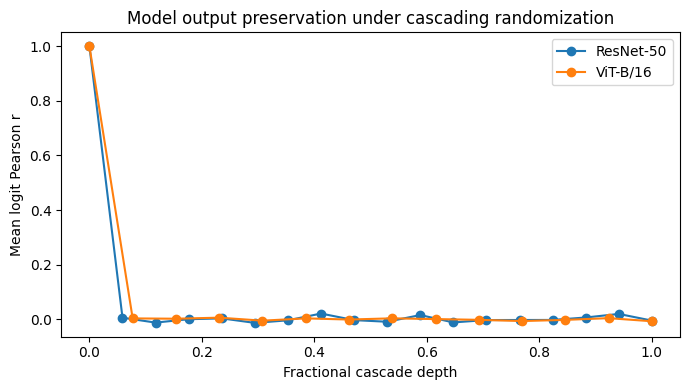

#### Logit correlation by cascade depth

depth,fractional_depth,ResNet-50,ViT-B/16
0,0.0000,1.0000,1.0000
1,0.0588,0.0063,
2,0.1176,-0.0117,
3,0.1765,0.0007,
4,0.2353,0.0038,
5,0.2941,-0.0127,
6,0.3529,-0.0033,
7,0.4118,0.0215,
8,0.4706,-0.0026,
9,0.5294,-0.0086,


Saved /Users/alexatran/saliency_and_attention/results/figures/table_logit_correlation.csv
Saved /Users/alexatran/saliency_and_attention/results/figures/activation_scales_resnet.png


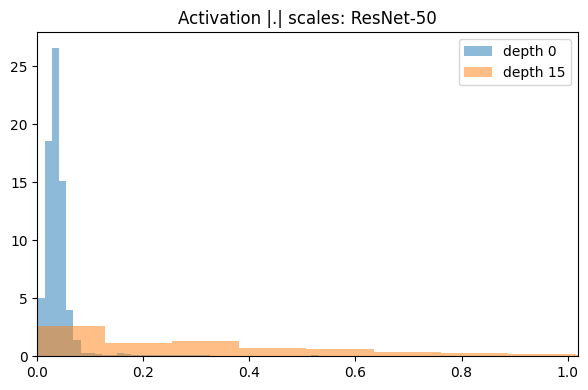

Saved /Users/alexatran/saliency_and_attention/results/figures/activation_scales_vit.png


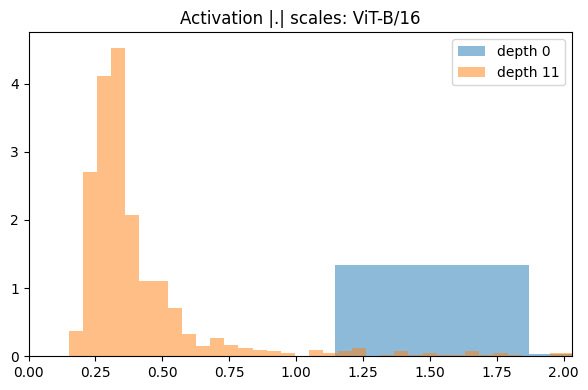

#### Activation scale summary statistics by depth

architecture,depth,n,mean,median,std,p99
ResNet-50,0,2048,0.0412171,0.0336318,0.0478477,0.26954
ResNet-50,1,2048,0.0634295,0.0529738,0.0778869,0.340149
ResNet-50,2,2048,0.0847408,0.0645588,0.139371,0.536429
ResNet-50,3,1024,0.842177,0.524549,0.993867,5.27855
ResNet-50,4,1024,0.795529,0.520375,0.923745,4.74696
ResNet-50,5,1024,0.789968,0.581109,0.780297,3.92654
ResNet-50,6,1024,0.867022,0.671157,0.685754,3.33314
ResNet-50,7,1024,0.860569,0.665839,0.711071,3.6637
ResNet-50,8,1024,0.878402,0.636412,0.794805,3.96793
ResNet-50,9,512,1.37865,0.84691,1.6261,8.26353


Saved /Users/alexatran/saliency_and_attention/results/figures/table_activation_scales.csv


In [10]:

mech = RESULTS_ROOT / "mechanistic"
if any((mech / ("logit_corr_%s.npy" % tag)).exists() for tag, _ in MECH_ARCH_TAGS):
    fig, ax = plt.subplots(figsize=(7, 4))
    for tag, label in MECH_ARCH_TAGS:
        p = mech / ("logit_corr_%s.npy" % tag)
        if p.exists():
            vals = np.load(p)
            ax.plot(_fraction_x(len(vals)), vals, marker="o", label=label)
    ax.set_xlabel("Fractional cascade depth")
    ax.set_ylabel("Mean logit Pearson r")
    ax.set_title("Model output preservation under cascading randomization")
    ax.legend()
    plt.tight_layout()
    _show_fig(fig, FIGURES_DIR / "logit_correlation.png")
    logit_table, logit_columns = build_logit_corr_table()
    _display_table(
        logit_table,
        "Logit correlation by cascade depth",
        csv_name="table_logit_correlation.csv",
        columns=logit_columns,
    )

for tag, label in MECH_ARCH_TAGS:
    files = sorted(mech.glob("activation_scale_%s_depth*.npy" % tag))
    if len(files) < 2:
        continue
    a0, a1 = np.load(files[0]).ravel(), np.load(files[-1]).ravel()
    combined = np.concatenate([a0, a1])
    combined = combined[np.isfinite(combined)]
    x_max = float(np.percentile(combined, 99)) if combined.size else np.nan
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(a0, bins=50, alpha=0.5, density=True, label="depth 0")
    ax.hist(a1, bins=50, alpha=0.5, density=True, label="depth %d" % (len(files) - 1))
    if np.isfinite(x_max) and x_max > 0:
        ax.set_xlim(0, x_max)
    ax.set_title("Activation |.| scales: %s" % label)
    ax.legend()
    plt.tight_layout()
    _show_fig(fig, FIGURES_DIR / ("activation_scales_%s.png" % tag))

_display_table(
    build_activation_scale_summary_table(),
    "Activation scale summary statistics by depth",
    csv_name="table_activation_scales.csv",
)


resnet50 occlusion gradient frac=0.10: n=500 images, mean AUC=0.800
resnet50 occlusion input_grad frac=0.10: n=500 images, mean AUC=0.824
resnet50 occlusion ig frac=0.10: n=500 images, mean AUC=0.813
resnet50 occlusion gradcam frac=0.10: n=500 images, mean AUC=0.776
resnet50 occlusion gbp frac=0.10: n=500 images, mean AUC=0.762
resnet50 occlusion gradient frac=0.20: n=500 images, mean AUC=0.758
resnet50 occlusion input_grad frac=0.20: n=500 images, mean AUC=0.791
resnet50 occlusion ig frac=0.20: n=500 images, mean AUC=0.770
resnet50 occlusion gradcam frac=0.20: n=500 images, mean AUC=0.722
resnet50 occlusion gbp frac=0.20: n=500 images, mean AUC=0.695
resnet50 occlusion gradient frac=0.30: n=500 images, mean AUC=0.720
resnet50 occlusion input_grad frac=0.30: n=500 images, mean AUC=0.757
resnet50 occlusion ig frac=0.30: n=500 images, mean AUC=0.729
resnet50 occlusion gradcam frac=0.30: n=500 images, mean AUC=0.674
resnet50 occlusion gbp frac=0.30: n=500 images, mean AUC=0.638
vit occlus

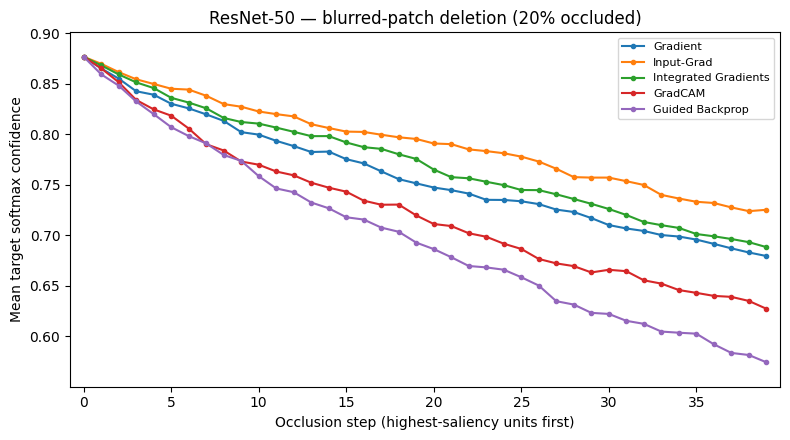

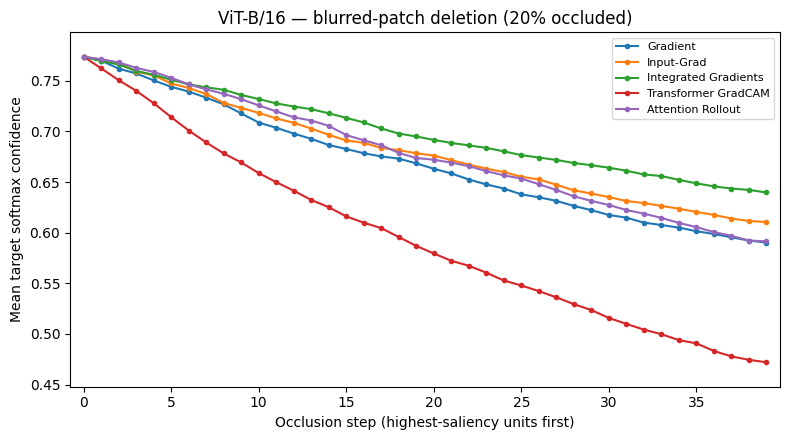

Saved /Users/alexatran/saliency_and_attention/results/figures/occlusion_faithfulness_curves_resnet50.png
Saved /Users/alexatran/saliency_and_attention/results/figures/occlusion_faithfulness_curves_vit.png


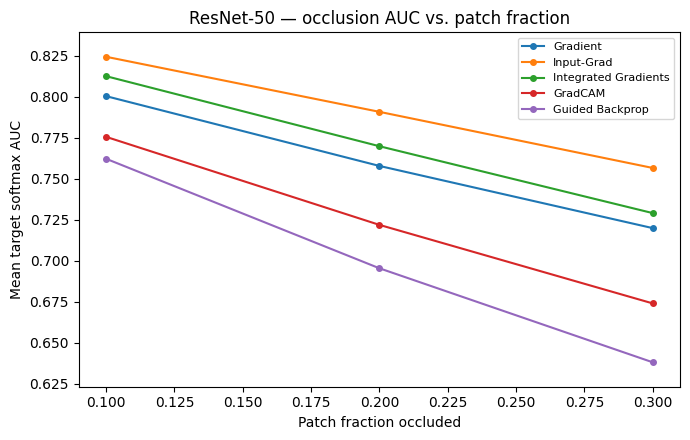

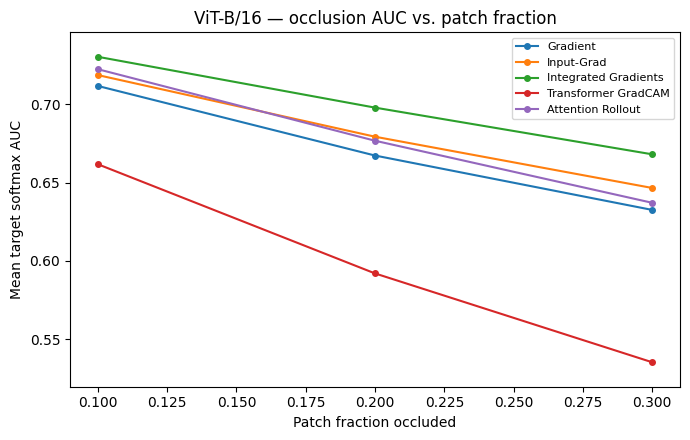

Saved /Users/alexatran/saliency_and_attention/results/figures/occlusion_auc_by_fraction_resnet50.png
Saved /Users/alexatran/saliency_and_attention/results/figures/occlusion_auc_by_fraction_vit.png


#### Occlusion faithfulness curves at 20% (mean target softmax by step)

architecture,step,Attention Rollout,GradCAM,Gradient,Guided Backprop,Input-Grad,Integrated Gradients,Transformer GradCAM
ResNet-50,0,,0.8769 ± 0.2148,0.8769 ± 0.2148,0.8769 ± 0.2148,0.8769 ± 0.2148,0.8769 ± 0.2148,
ResNet-50,1,,0.8655 ± 0.2333,0.8654 ± 0.2284,0.8596 ± 0.2440,0.8700 ± 0.2228,0.8684 ± 0.2264,
ResNet-50,2,,0.8518 ± 0.2491,0.8553 ± 0.2451,0.8483 ± 0.2566,0.8617 ± 0.2380,0.8595 ± 0.2415,
ResNet-50,3,,0.8342 ± 0.2703,0.8428 ± 0.2610,0.8327 ± 0.2804,0.8546 ± 0.2505,0.8516 ± 0.2539,
ResNet-50,4,,0.8249 ± 0.2810,0.8394 ± 0.2693,0.8201 ± 0.2942,0.8500 ± 0.2593,0.8459 ± 0.2651,
ResNet-50,5,,0.8186 ± 0.2880,0.8304 ± 0.2806,0.8072 ± 0.3109,0.8453 ± 0.2651,0.8363 ± 0.2768,
ResNet-50,6,,0.8059 ± 0.3024,0.8259 ± 0.2838,0.7984 ± 0.3210,0.8444 ± 0.2639,0.8316 ± 0.2831,
ResNet-50,7,,0.7903 ± 0.3171,0.8199 ± 0.2929,0.7911 ± 0.3278,0.8383 ± 0.2729,0.8259 ± 0.2884,
ResNet-50,8,,0.7841 ± 0.3255,0.8134 ± 0.2980,0.7797 ± 0.3376,0.8301 ± 0.2806,0.8163 ± 0.2997,
ResNet-50,9,,0.7732 ± 0.3338,0.8023 ± 0.3126,0.7739 ± 0.3402,0.8275 ± 0.2854,0.8123 ± 0.3030,


Saved /Users/alexatran/saliency_and_attention/results/figures/table_occlusion_faithfulness.csv


#### Occlusion AUC summary by patch fraction

architecture,method,patch_fraction,n_tiles,n_occluded,n_images,auc_mean,auc_std,auc_median
ResNet-50,Gradient,0.10,196,20,500,0.8004,0.2921,0.9922
ResNet-50,Input-Grad,0.10,196,20,500,0.8244,0.2738,0.9958
ResNet-50,Integrated Gradients,0.10,196,20,500,0.8126,0.2863,0.9938
ResNet-50,GradCAM,0.10,196,20,500,0.7755,0.3105,0.9883
ResNet-50,Guided Backprop,0.10,196,20,500,0.7622,0.3165,0.9654
ResNet-50,Gradient,0.20,196,39,500,0.7578,0.3194,0.9689
ResNet-50,Input-Grad,0.20,196,39,500,0.7908,0.2967,0.9844
ResNet-50,Integrated Gradients,0.20,196,39,500,0.7698,0.3134,0.9762
ResNet-50,GradCAM,0.20,196,39,500,0.7218,0.3383,0.9424
ResNet-50,Guided Backprop,0.20,196,39,500,0.6953,0.3351,0.8478


Saved /Users/alexatran/saliency_and_attention/results/figures/table_occlusion_auc.csv


In [11]:

def _print_occlusion_diagnostics():
    summary = load_occlusion_auc_summary(RESULTS_ROOT, ARCHS)
    if not summary:
        print("No occlusion AUC summary found (run --experiment occlusion first).")
        return
    for arch in ["resnet50", "vit"]:
        title = ARCHS[arch]["title"]
        arch_rows = [r for r in summary if r.get("architecture") == title]
        if not arch_rows:
            print(f"{arch} occlusion summary NOT FOUND")
            continue
        for patch_fraction in DEFAULT_PATCH_FRACTIONS:
            frac_rows = [
                r for r in arch_rows if float(r["patch_fraction"]) == patch_fraction
            ]
            for row in frac_rows:
                print(
                    f"{arch} occlusion {row['method']} "
                    f"frac={patch_fraction:.2f}: "
                    f"n={row.get('n_images', '?')} images, "
                    f"mean AUC={float(row['auc_mean']):.3f}"
                )
        if len(arch_rows) == 1 and arch_rows[0].get("n_images") == 4:
            print(
                f"{arch}: reading smoke-test occlusion results; rerun with "
                "--num-images 500 --force-recompute before interpreting bars."
            )


def plot_occlusion_faithfulness():
    _print_occlusion_diagnostics()
    mech_tags = {"resnet50": "resnet", "vit": "vit"}
    for out in plot_occlusion_faithfulness_curves(
        RESULTS_ROOT,
        ARCHS,
        FIGURES_DIR,
        mech_arch_tags=mech_tags,
        patch_fraction=0.20,
        dpi=150,
        show=True,
    ):
        print("Saved", out)
    for auc_out in plot_occlusion_auc_by_fraction(
        RESULTS_ROOT,
        ARCHS,
        FIGURES_DIR,
        dpi=150,
        show=True,
    ):
        print("Saved", auc_out)
    occ_table, occ_columns = build_occlusion_faithfulness_table(patch_fraction=0.20)
    _display_table(
        occ_table,
        "Occlusion faithfulness curves at 20% (mean target softmax by step)",
        csv_name="table_occlusion_faithfulness.csv",
        columns=occ_columns,
    )
    _display_table(
        build_occlusion_auc_table(),
        "Occlusion AUC summary by patch fraction",
        csv_name="table_occlusion_auc.csv",
    )


plot_occlusion_faithfulness()


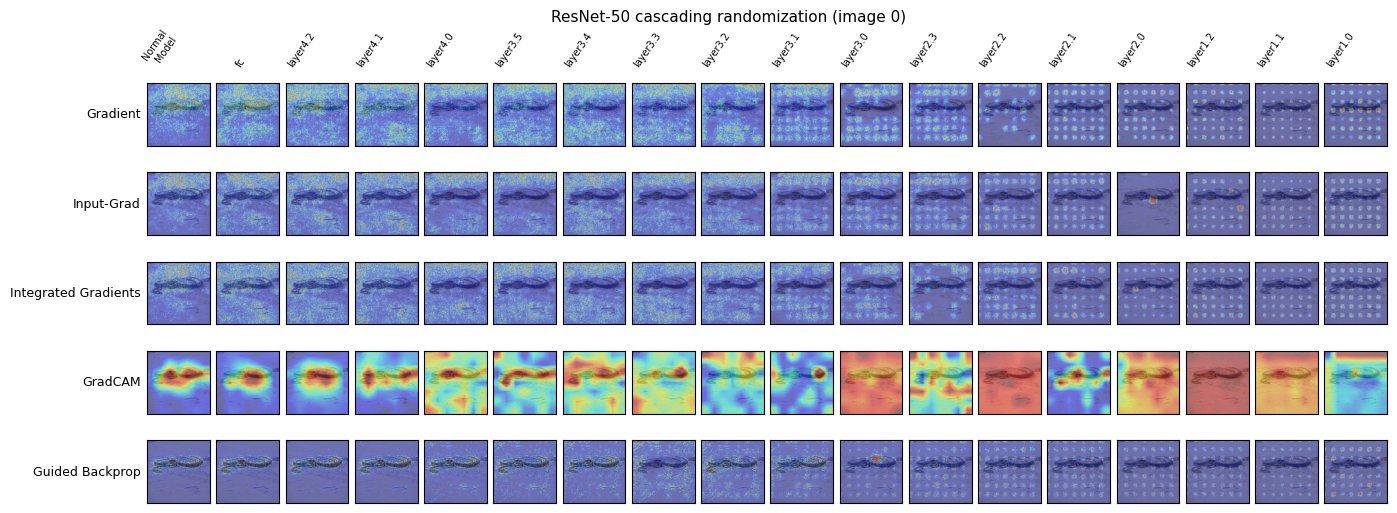

resnet50 image 0 -> cascade_grid_resnet50.png (jet overlay), cascade_grid_resnet50_masks.png
  extras: cascade_grid_resnet50_bwr_pct.png, cascade_grid_resnet50_jet_pct.png, cascade_grid_resnet50_turbo_pct.png, cascade_grid_resnet50_hot_pct.png, cascade_grid_resnet50_bwr_absmax.png


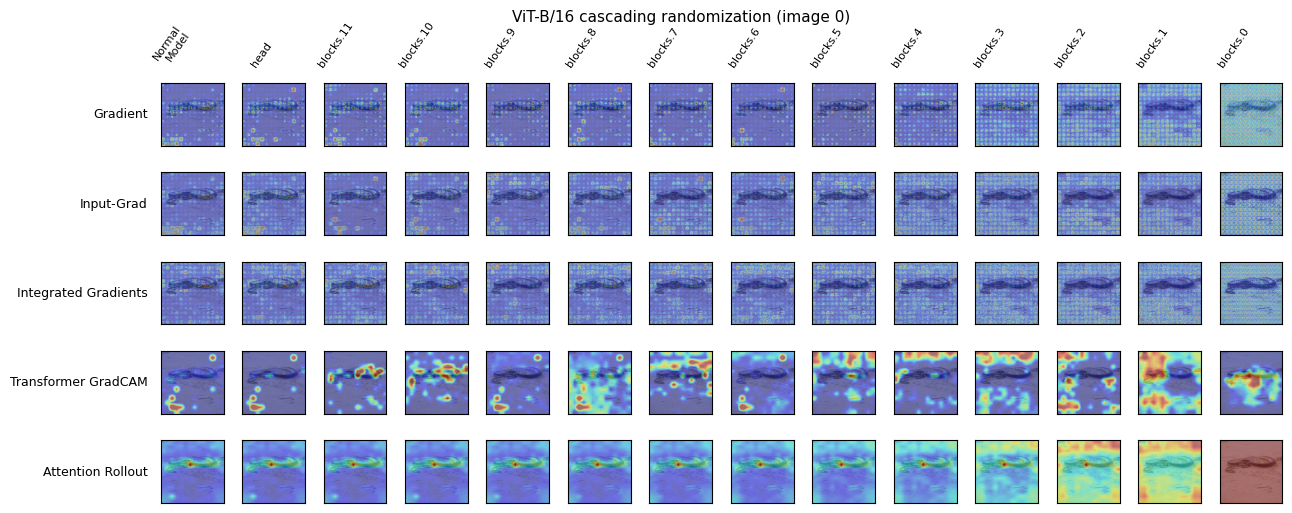

vit image 0 -> cascade_grid_vit.png (jet overlay), cascade_grid_vit_masks.png
  extras: cascade_grid_vit_bwr_pct.png, cascade_grid_vit_jet_pct.png, cascade_grid_vit_turbo_pct.png, cascade_grid_vit_hot_pct.png, cascade_grid_vit_bwr_absmax.png
Figures saved to /Users/alexatran/saliency_and_attention/results/figures


In [12]:

for arch, cfg in ARCHS.items():
    qual_path = RESULTS_ROOT / arch / "qual_bundle.npz"
    if not qual_path.exists():
        print("Skip %s: no qual_bundle.npz (run qual-only Modal job or pipeline with skip_qual=False)" % arch)
        continue
    data = np.load(qual_path, allow_pickle=True)
    img_idx = int(data["image_index"]) if "image_index" in data.files else 0
    order = list(data["order"])
    methods = [m for m in cfg["methods"] if ("baseline_" + m) in data.files]
    depth_indices = select_depth_indices(len(order) + 1, max_cols=None)
    base_title = cfg["title"] + " cascading randomization (image %d)" % img_idx

    # Primary (last-commit style): jet heatmap blended on the input image.
    plot_cascade_paper_grid(
        qual_path,
        methods,
        depth_indices=depth_indices,
        out_path=FIGURES_DIR / ("cascade_grid_%s.png" % arch),
        title=base_title,
        arch=arch,
        overlay=True,
        heatmap_cmap="jet",
        max_depth_cols=None,
        show=True,
    )
    # Secondary: grayscale masks (overlay=False).
    plot_cascade_paper_grid(
        qual_path,
        methods,
        depth_indices=depth_indices,
        out_path=FIGURES_DIR / ("cascade_grid_%s_masks.png" % arch),
        title=base_title + " [masks]",
        arch=arch,
        overlay=False,
        mask_cmap="gray",
        display_norm="minmax",
        max_depth_cols=None,
        show=False,
    )
    # Optional extra modes (percentile / turbo / bwr, etc.).
    saved_extra = []
    for suffix, preset in CASCADE_DISPLAY_PRESETS.items():
        if suffix == "overlay_jet":
            continue
        out = FIGURES_DIR / ("cascade_grid_%s_%s.png" % (arch, suffix))
        plot_cascade_paper_grid(
            qual_path,
            methods,
            depth_indices=depth_indices,
            out_path=out,
            title=base_title + " [%s]" % suffix,
            arch=arch,
            max_depth_cols=None,
            show=False,
            **preset,
        )
        saved_extra.append(out.name)
    print(
        "%s image %d -> cascade_grid_%s.png (jet overlay), cascade_grid_%s_masks.png"
        % (arch, img_idx, arch, arch)
    )
    if saved_extra:
        print("  extras:", ", ".join(saved_extra))

# Optional per-method vertical strips for slides
for arch, method, title in [
    ("resnet50", "gbp", "ResNet-50 GBP"),
    ("resnet50", "input_grad", "ResNet-50 Input-Grad"),
    ("resnet50", "ig", "ResNet-50 IG"),
    ("vit", "ig", "ViT IG"),
    ("vit", "transformer_gradcam", "ViT Transformer GradCAM"),
    ("vit", "attention_rollout", "ViT attention rollout"),
]:
    plot_cascading_grid(
        RESULTS_ROOT / arch / "qual_bundle.npz",
        method,
        out_path=FIGURES_DIR / ("cascade_%s_%s.png" % (arch, method)),
        title=title,
        arch=arch,
        overlay=True,
        show=False,
    )

print("Figures saved to", FIGURES_DIR)


In [13]:
import json
import random

manifest_path = RESULTS_ROOT / "diagnostics" / "subset_manifest_first500.json"
if not manifest_path.exists():
    raise FileNotFoundError(
        "Missing %s — run from repo root or re-download results." % manifest_path
    )
manifest = json.loads(manifest_path.read_text())

# Pick a random qual index (must be < num_images passed to Modal qual-only).
QUAL_NUM_IMAGES = 500
qual_image_index = random.randint(0, QUAL_NUM_IMAGES - 1)
print("Random qual image_index:", qual_image_index)
print(manifest[qual_image_index]["filename"], "—", manifest[qual_image_index]["class_name"])

# Browse by class name (optional)
for row in manifest:
    if "retriever" in row["class_name"].lower():
        print(row["dataset_index"], row["filename"], row["class_name"])

FileNotFoundError: Missing /Users/alexatran/saliency_and_attention/results/diagnostics/subset_manifest_first500.json — run from repo root or re-download results.